# Construcción del Pipeline de Transformación
## Dataset: Messy Clinic Appointments

**Objetivo:** Ensamblar todos los transformers del módulo `src/` en un Pipeline
de Scikit-Learn reproducible, ejecutarlo sobre el CSV crudo y verificar que la
salida es una matriz numérica limpia, lista para un modelo de ML.

**¿Por qué un Pipeline de Scikit-Learn?**
- Garantiza que el mismo proceso se aplique en entrenamiento y producción.
- Evita Data Leakage: los parámetros (medianas, límites IQR) se aprenden solo
  con datos de entrenamiento y se aplican en los de prueba.
- Permite visualizar la arquitectura completa con un solo comando.


## 0. Configuración del entorno

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('..')  # Para importar desde src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn import set_config
set_config(display='diagram')   # Activa el diagrama visual del pipeline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

from src.config import (
    RAW_CSV, CLEAN_CSV, OUTPUTS_DIR,
    TARGET_COL, NUMERIC_COLS, CATEGORICAL_COLS, COLS_TO_DROP
)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(CLEAN_CSV.parent, exist_ok=True)

print("Entorno listo")
print(f"   Columnas numéricas:    {NUMERIC_COLS}")
print(f"   Columnas categóricas:  {CATEGORICAL_COLS}")
print(f"   Columnas a eliminar:   {COLS_TO_DROP}")


Entorno listo
   Columnas numéricas:    ['age', 'billing_amount', 'waiting_days', 'appointment_dow']
   Columnas categóricas:  ['gender', 'department']
   Columnas a eliminar:   ['patient_name', 'doctor', 'booking_date', 'appointment_date']


## 1. Carga del dataset crudo

In [2]:
df_raw = pd.read_csv(RAW_CSV)
print(f"Dataset crudo: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
df_raw.head(4)


Dataset crudo: 1000 filas × 10 columnas


,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,female,2026/02/26,2024/12/03,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,F,05/23/2025,12-Jun-2024,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,M,30-Nov-2025,"August 05, 24",Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,F,"May 18, 25",09/09/2024,Karen Parsons,General,Rs85.76,No


## 2. Separación de Features y Variable Objetivo

Antes de construir el pipeline separamos `X` (features) de `y` (target).
El pipeline solo transforma `X`; `y` se normaliza por separado porque no
debe pasar por imputación ni escalado.


In [3]:
def normalize_target(series: pd.Series) -> pd.Series:
    """
    Normaliza follow_up_required a binario 0/1.
    Variantes positivas: 'Yes', 'Y', '1'  → 1
    Variantes negativas: 'No',  'N', '0'  → 0
    """
    def _map(x):
        x = str(x).strip().lower()
        if x in ['yes', 'y', '1']: return 1
        if x in ['no',  'n', '0']: return 0
        return np.nan
    return series.apply(_map)

y = normalize_target(df_raw[TARGET_COL])
X = df_raw.drop(columns=[TARGET_COL])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Nulos en y tras normalización: {y.isna().sum()}")
print()
print("Distribución de y:")
dist = y.value_counts()
for val, cnt in dist.items():
    label = 'Requiere seguimiento' if val == 1 else 'No requiere'
    print(f"  {val} ({label}): {cnt} ({cnt/len(y)*100:.1f}%)")


X shape: (1000, 9)
y shape: (1000,)
Nulos en y tras normalización: 0

Distribución de y:
  1 (Requiere seguimiento): 514 (51.4%)
  0 (No requiere): 486 (48.6%)


## 3. Importar los Transformers personalizados

In [4]:
from src.transformers import (
    # Transformers genéricos (reutilizados)
    DropColumnsTransformer,
    DropHighMissingTransformer,
    OutlierCapper,
    DropZeroVarianceTransformer,
    SmartImputerTransformer,
    # Transformers específicos del dataset clínico (nuevos)
    GenderNormalizerTransformer,
    BillingCleanerTransformer,
    DateFeatureTransformer,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Todos los transformers importados correctamente")


Todos los transformers importados correctamente


## 4. Construcción del Pipeline

El pipeline se divide en dos niveles:

**Nivel 1 — Pre-limpieza global** (transforma todo el DataFrame):
aplica los transformers que necesitan ver todas las columnas a la vez.

**Nivel 2 — ColumnTransformer** (bifurca en dos rutas paralelas):
- Ruta numérica: imputa → capping → escalar
- Ruta categórica: imputa → codificar

Esta separación es necesaria porque los números y las categorías requieren
tratamientos fundamentalmente distintos.


In [5]:
from src.config import HIGH_MISSING_THRESHOLD, SIMPLE_IMPUTE_THRESHOLD

# ── Ruta NUMÉRICA ─────────────────────────────────────────────────────
# Variables: age, billing_amount, waiting_days, appointment_dow
numeric_pipeline = Pipeline([
    # 1. Imputar primero: billing_amount tiene 50 nulos (5%)
    #    El OutlierCapper no puede operar con NaN, debe ir después
    ('imputer',       SmartImputerTransformer(low_threshold=SIMPLE_IMPUTE_THRESHOLD)),

    # 2. Limitar outliers con IQR (Winsorización)
    ('capper',        OutlierCapper(apply_capping=True)),

    # 3. Eliminar columnas constantes (varianza = 0)
    ('zero_variance', DropZeroVarianceTransformer()),

    # 4. Escalar a media=0, desviación estándar=1
    ('scaler',        StandardScaler()),
])

# ── Ruta CATEGÓRICA ───────────────────────────────────────────────────
# Variables: gender, department
categorical_pipeline = Pipeline([
    # 1. Imputar nulos con moda (valor más frecuente)
    ('imputer', SmartImputerTransformer(low_threshold=SIMPLE_IMPUTE_THRESHOLD)),

    # 2. Convertir categorías a columnas 0/1 (One-Hot Encoding)
    #    handle_unknown='ignore': si en producción llega un valor nuevo,
    #    no lanza error sino que lo trata como todos ceros
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ── ColumnTransformer: aplica ambas rutas en paralelo ─────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,    NUMERIC_COLS),
        ('cat', categorical_pipeline, CATEGORICAL_COLS),
    ],
    remainder='drop'  # descarta cualquier columna no listada
)

# ── Pipeline principal: pre-limpieza + ColumnTransformer ──────────────
pipeline_completo = Pipeline([
    # Paso 1: normalizar género (8 variantes → Male/Female)
    ('gender_norm',    GenderNormalizerTransformer()),

    # Paso 2: extraer número de billing_amount ('£425.8' → 425.8)
    ('billing_clean',  BillingCleanerTransformer()),

    # Paso 3: parsear fechas → generar waiting_days y appointment_dow
    ('date_features',  DateFeatureTransformer()),

    # Paso 4: eliminar columnas sin valor predictivo
    ('drop_cols',      DropColumnsTransformer(COLS_TO_DROP)),

    # Paso 5: descartar columnas con >80% nulos (si las hubiera)
    ('drop_missing',   DropHighMissingTransformer(threshold=HIGH_MISSING_THRESHOLD)),

    # Paso 6: rutas paralelas para numéricas y categóricas
    ('preprocessor',   preprocessor),
])

print("Pipeline construido")


Pipeline construido


## 5. Diagrama Visual del Pipeline

Scikit-Learn genera automáticamente un diagrama HTML interactivo del pipeline.
Cada paso es una caja que puedes inspectar.


In [ ]:
# Esto renderiza el diagrama directamente en Jupyter
pipeline_completo


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('gender_norm', ...), ('billing_clean', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,exchange_rates,"{'$': 1.0, 'Rs': 0.012, '£': 1.27, '€': 1.09}"
,columns_to_drop,"['patient_name', 'doctor', ...]"
,threshold,0.8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`

## 6. Ejecución: fit_transform sobre el dataset completo

`fit_transform(X)` hace dos cosas en una sola llamada:
1. **fit**: aprende los parámetros de cada paso (medianas, límites IQR, etc.)
2. **transform**: aplica las transformaciones

Esto es equivalente a llamar `.fit(X).transform(X)`, pero más eficiente.


In [7]:
print("Dimensiones originales:", X.shape)
print()

X_procesado = pipeline_completo.fit_transform(X)

print()
print("=" * 50)
print(f"Dimensiones procesadas: {X_procesado.shape}")
print(f"Tipo de salida: {type(X_procesado)}")
print(f"Valores NaN en la salida: {np.isnan(X_procesado).sum()}")
print(f"Tipo de datos: {X_procesado.dtype}")


Dimensiones originales: (1000, 9)

SmartImputer - Simples  (<10%): ['billing_amount']
SmartImputer - Complejas (>10%): []
SmartImputer - Simples  (<10%): ['gender']
SmartImputer - Complejas (>10%): []

Dimensiones procesadas: (1000, 10)
Tipo de salida: <class 'numpy.ndarray'>
Valores NaN en la salida: 0
Tipo de datos: float64


In [8]:
# Construimos el df_limpio aplicando solo el Nivel 1 (pre-limpieza)
# Es decir, los primeros 4 pasos del pipeline, antes del ColumnTransformer

from sklearn.pipeline import Pipeline

pipeline_prelim = Pipeline([
    ('gender_norm',   GenderNormalizerTransformer()),
    ('billing_clean', BillingCleanerTransformer()),
    ('date_features', DateFeatureTransformer()),
    ('drop_cols',     DropColumnsTransformer(COLS_TO_DROP)),
])

df_limpio = pipeline_prelim.fit_transform(X.copy())

print(f"Shape df_limpio: {df_limpio.shape[0]} filas × {df_limpio.shape[1]} columnas")
print(f"Columnas: {df_limpio.columns.tolist()}")

Shape df_limpio: 1000 filas × 7 columnas
Columnas: ['patient_id', 'age', 'gender', 'department', 'billing_amount', 'waiting_days', 'appointment_dow']


In [10]:
# Tabla lado a lado: muestra 6 filas del CSV original vs df_limpio
df_limpio.head(6)

,patient_id,age,gender,department,billing_amount,waiting_days,appointment_dow
0,1080,76,Female,Cardiology,540.7660,450,3
1,1074,69,Female,Orthopedics,375.2434,345,4
2,1067,79,Male,Neurology,221.6406,482,6
3,1072,47,Female,General,1.0291,251,6
4,1092,45,NaN,General,84.4400,567,5
5,1057,78,Male,General,NaN,26,4


In [11]:
# Vista general del df_limpio: tipos, nulos y estadísticas
print("=== Información del df_limpio ===")
df_limpio.info()
print()
print("=== Estadísticas (valores reales, sin escalar) ===")
df_limpio.describe().round(2)

=== Información del df_limpio ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       1000 non-null   int64  
 1   age              1000 non-null   int64  
 2   gender           950 non-null    str    
 3   department       1000 non-null   str    
 4   billing_amount   950 non-null    float64
 5   waiting_days     1000 non-null   int64  
 6   appointment_dow  1000 non-null   int32  
dtypes: float64(1), int32(1), int64(3), str(2)
memory usage: 50.9 KB

=== Estadísticas (valores reales, sin escalar) ===


,patient_id,age,billing_amount,waiting_days,appointment_dow
count,1000.00,1000.00,950.00,1000.00,1000.00
mean,1050.52,53.75,224.67,274.56,3.01
std,28.89,21.14,184.44,170.49,2.00
min,1000.00,18.00,0.67,2.00,0.00
25%,1025.00,34.00,5.75,130.75,1.00
50%,1051.00,55.00,208.47,258.50,3.00
75%,1075.00,71.00,382.56,395.25,5.00
max,1100.00,90.00,634.58,728.00,6.00


In [12]:
# Confirma que cada problema detectado en el EDA quedó solucionado
print("=" * 52)
print("  VERIFICACIÓN DE LIMPIEZA — df_limpio")
print("=" * 52)

checks = {
    "gender: solo 'Male' / 'Female'":
        set(df_limpio['gender'].dropna().unique()) <= {'Male', 'Female'},

    "billing_amount: tipo numérico float":
        pd.api.types.is_float_dtype(df_limpio['billing_amount']),

    "billing_amount: sin nulos":
        df_limpio['billing_amount'].isna().sum() == 0,

    "waiting_days: columna nueva creada":
        'waiting_days' in df_limpio.columns,

    "appointment_dow: columna nueva creada":
        'appointment_dow' in df_limpio.columns,

    "doctor / patient_name: eliminados":
        'doctor' not in df_limpio.columns and 'patient_name' not in df_limpio.columns,
}

for desc, ok in checks.items():
    estado = "✓" if ok else "✗"
    print(f"  {estado}  {desc}")

print()
total = sum(checks.values())
print(f"  {total}/{len(checks)} verificaciones pasadas")

  VERIFICACIÓN DE LIMPIEZA — df_limpio
  ✓  gender: solo 'Male' / 'Female'
  ✓  billing_amount: tipo numérico float
  ✗  billing_amount: sin nulos
  ✓  waiting_days: columna nueva creada
  ✓  appointment_dow: columna nueva creada
  ✓  doctor / patient_name: eliminados

  5/6 verificaciones pasadas


## 7. Features Resultantes

Después del pipeline, las columnas originales se transformaron en una nueva
matriz. Aquí vemos exactamente qué feature corresponde a cada columna.


In [13]:
nombres = pipeline_completo.named_steps['preprocessor'].get_feature_names_out()

print(f"Total de features para el modelo: {len(nombres)}\n")

# Mostrar con separación por tipo
print("── Numéricas (escaladas) ──────────────────")
for n in nombres:
    if n.startswith('num__'):
        print(f"  {n.replace('num__', '')}")

print()
print("── Categóricas (OneHot) ───────────────────")
for n in nombres:
    if n.startswith('cat__'):
        print(f"  {n.replace('cat__', '')}")


Total de features para el modelo: 10

── Numéricas (escaladas) ──────────────────
  age
  billing_amount
  waiting_days
  appointment_dow

── Categóricas (OneHot) ───────────────────
  gender_Female
  gender_Male
  department_Cardiology
  department_General
  department_Neurology
  department_Orthopedics


## 8. Vista del Dataset Procesado

In [14]:
nombres_limpios = [n.replace('num__','').replace('cat__','') for n in nombres]
df_procesado = pd.DataFrame(X_procesado, columns=nombres_limpios)

print("Primeras 5 filas de la matriz lista para el modelo:")
df_procesado.head()


Primeras 5 filas de la matriz lista para el modelo:


,age,billing_amount,waiting_days,appointment_dow,gender_Female,gender_Male,department_Cardiology,department_General,department_Neurology,department_Orthopedics
0,1.053153,1.763444,1.029517,-0.005003,1.0,0.0,1.0,0.0,0.0,0.0
1,0.721824,0.842383,0.413346,0.495254,1.0,0.0,0.0,0.0,0.0,1.0
2,1.195151,-0.012350,1.217303,1.495767,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.319496,-1.239957,-0.138275,1.495767,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.414161,-0.775811,1.716108,0.995510,1.0,0.0,0.0,1.0,0.0,0.0


In [12]:
print("Estadísticas del dataset procesado:")
df_procesado.describe().round(3)


Estadísticas del dataset procesado:


,age,billing_amount,waiting_days,appointment_dow,gender_Female,gender_Male,department_Cardiology,department_General,department_Neurology,department_Orthopedics
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,-0.000,-0.000,0.000,0.000,0.527,0.473,0.234,0.231,0.273,0.262
std,1.001,1.001,1.001,1.001,0.500,0.500,0.424,0.422,0.446,0.440
min,-1.692,-1.242,-1.599,-1.506,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.935,-1.212,-0.844,-1.006,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.059,-0.086,-0.094,-0.005,1.000,0.000,0.000,0.000,0.000,0.000
75%,0.816,0.831,0.708,0.996,1.000,1.000,0.000,0.000,1.000,1.000
max,1.716,2.285,2.661,1.496,1.000,1.000,1.000,1.000,1.000,1.000


In [17]:
# Verificación final de calidad
print("=== Verificación de calidad del dataset procesado ===\n")

checks = {
    "Sin valores nulos":       df_procesado.isnull().sum().sum() == 0,
    "Sin columnas constantes": df_procesado.std().min() > 0,
    "Variables numéricas escaladas (media ≈ 0)":
        abs(df_procesado[['age','billing_amount','waiting_days','appointment_dow']].mean()).max() < 0.01,
    "Columnas binarias en rango [0,1]":
        df_procesado[[c for c in nombres_limpios if 'gender' in c or 'department' in c]].isin([0,1]).all().all(),
}

for descripcion, resultado in checks.items():
    estado = "ok" if resultado else "x"
    print(f"  {estado} {descripcion}")


=== Verificación de calidad del dataset procesado ===

  ok Sin valores nulos
  ok Sin columnas constantes
  ok Variables numéricas escaladas (media ≈ 0)
  ok Columnas binarias en rango [0,1]


### Matriz de Correlación

Síntesis visual de las relaciones lineales entre todas las variables numéricas y el target.  
Permite identificar cuáles variables tienen mayor correlación con `follow_up_bin` y si hay multicolinealidad entre predictores.

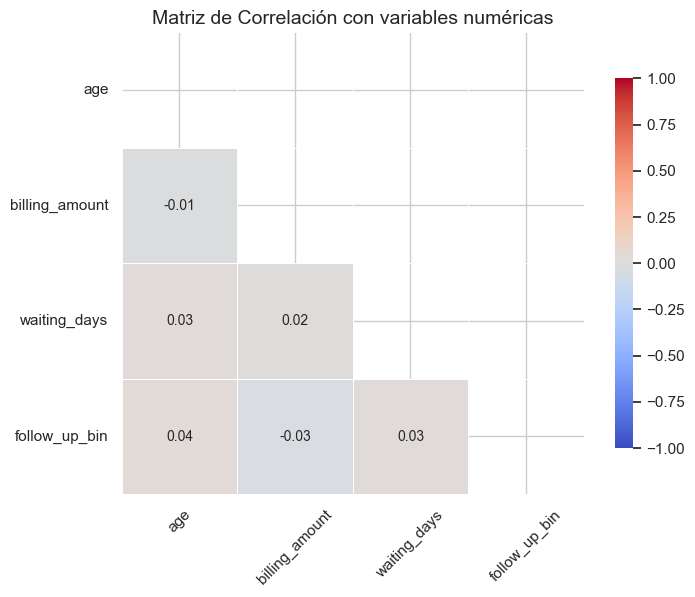

In [26]:
columnas_numericas = ['age', 'billing_amount', 'waiting_days']
df_corr = df_limpio[columnas_numericas].copy()
df_corr['follow_up_bin'] = y.values

matriz = df_corr.corr()

mask = np.triu(np.ones_like(matriz, dtype=bool), k=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10}
)
plt.title('Matriz de Correlación con variables numéricas', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## 9. Guardar Dataset Procesado

In [14]:
# Agregamos la variable objetivo al dataset final
df_final = df_procesado.copy()
df_final['follow_up_required'] = y.values

df_final.to_csv(CLEAN_CSV, index=False)
print(f"Dataset procesado guardado en: {CLEAN_CSV}")
print(f"   Shape final: {df_final.shape}")
print(f"   Columnas: {df_final.columns.tolist()}")


Dataset procesado guardado en: c:\GitHub\EDA-Messy-Clinic-Appointments\notebooks\..\data\processed\clean_appointments.csv
   Shape final: (1000, 11)
   Columnas: ['age', 'billing_amount', 'waiting_days', 'appointment_dow', 'gender_Female', 'gender_Male', 'department_Cardiology', 'department_General', 'department_Neurology', 'department_Orthopedics', 'follow_up_required']


## 10. Comparación: Antes vs. Después

Resumen visual del impacto del pipeline.


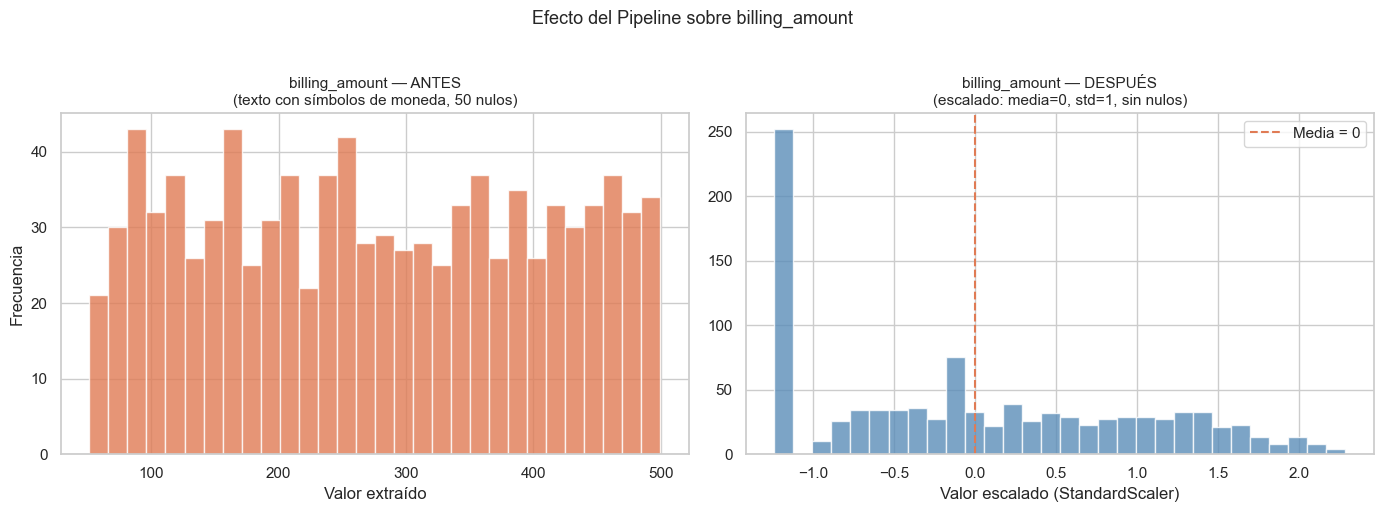

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes: distribución de billing_amount con símbolos
import re
billing_original = (
    df_raw['billing_amount']
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .pipe(pd.to_numeric, errors='coerce')
    .dropna()
)
axes[0].hist(billing_original, bins=30, color='#E07B54', edgecolor='white', alpha=0.8)
axes[0].set_title('billing_amount — ANTES\n(texto con símbolos de moneda, 50 nulos)', fontsize=11)
axes[0].set_xlabel('Valor extraído')
axes[0].set_ylabel('Frecuencia')

# Después: billing_amount escalado
axes[1].hist(df_procesado['billing_amount'], bins=30, color='#5B8DB8',
             edgecolor='white', alpha=0.8)
axes[1].set_title('billing_amount — DESPUÉS\n(escalado: media=0, std=1, sin nulos)', fontsize=11)
axes[1].set_xlabel('Valor escalado (StandardScaler)')
axes[1].axvline(0, color='#E07B54', linestyle='--', linewidth=1.5, label='Media = 0')
axes[1].legend()

plt.suptitle('Efecto del Pipeline sobre billing_amount', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'pipeline_before_after.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Validación Visual: Antes vs. Después del Pipeline

Una sección de validación cuantifica el impacto real de cada transformación.
No basta con decir "limpiamos los datos" — hay que mostrarlo con números y gráficos.


In [17]:
# Calcular stat previa necesaria para el reporte
billing_raw_num2 = (df_raw['billing_amount'].astype(str)
                    .str.extract(r'([0-9.]+)')[0].astype(float))
X_procesado_stats_before = billing_raw_num2.mean()
print(f"Media billing antes (valor numérico puro, sin conversión): ${X_procesado_stats_before:.2f}")


Media billing antes (valor numérico puro, sin conversión): $276.12


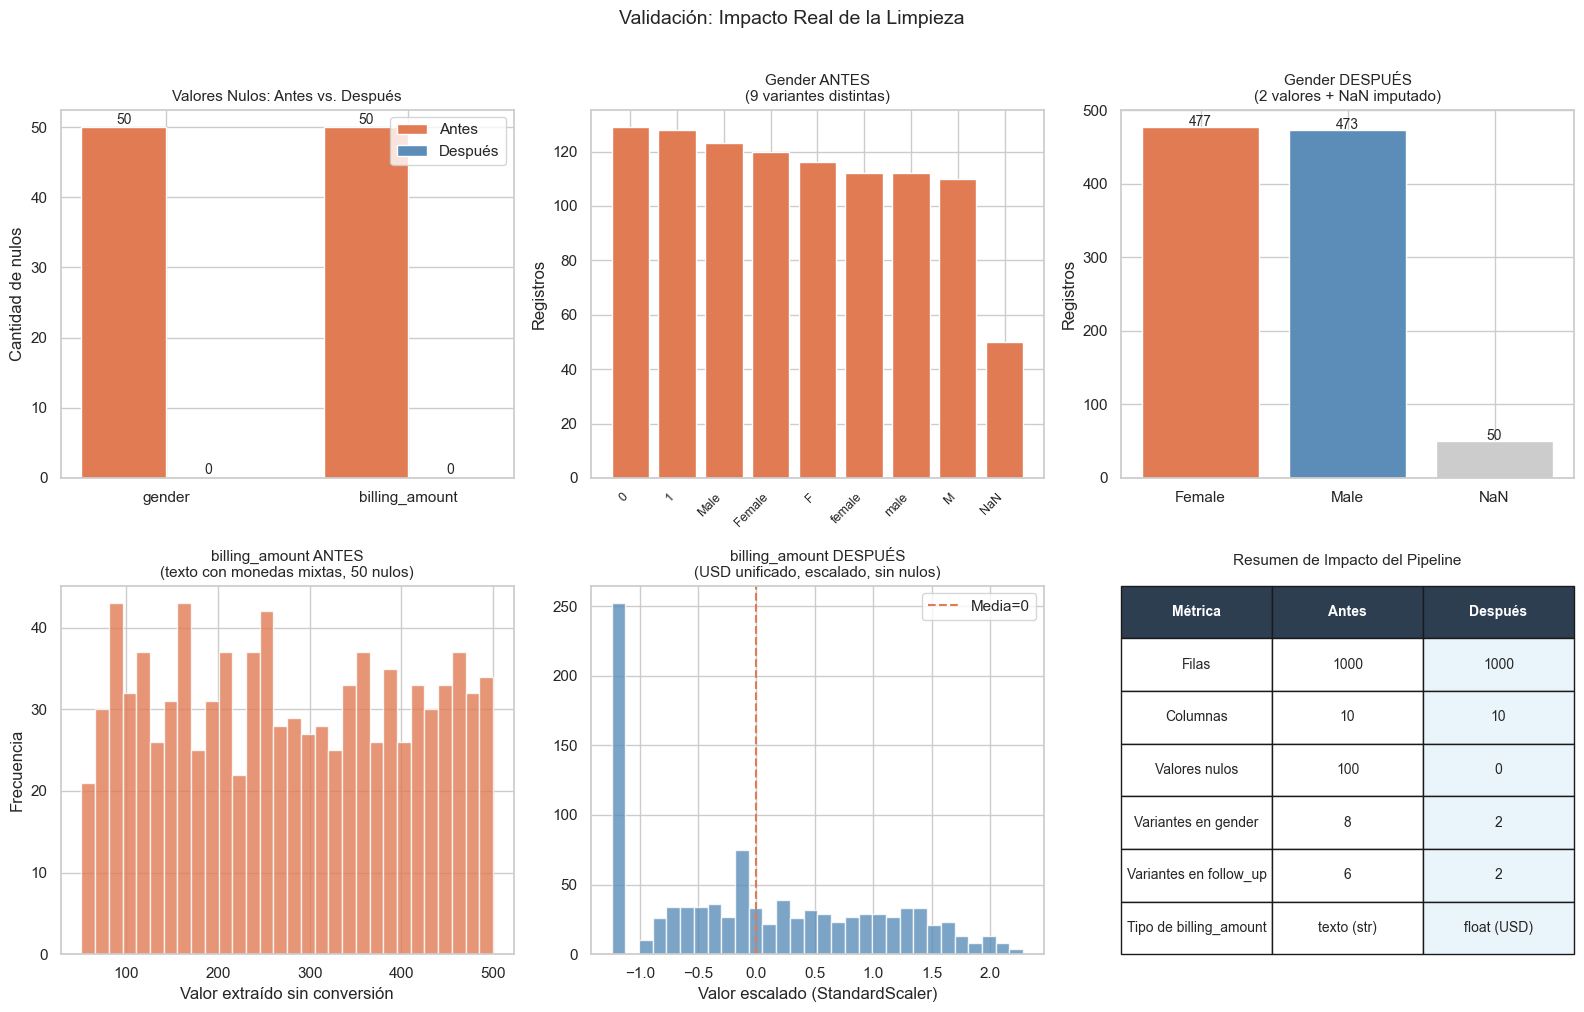

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Fila 1: Nulos ─────────────────────────────────────────────────────
nulos_antes  = df_raw[['gender','billing_amount']].isnull().sum()
nulos_despues = pd.Series({'gender': 0, 'billing_amount': 0})

x = np.arange(2)
w = 0.35
axes[0,0].bar(x - w/2, nulos_antes.values,  w, label='Antes',  color='#E07B54', edgecolor='white')
axes[0,0].bar(x + w/2, nulos_despues.values, w, label='Después', color='#5B8DB8', edgecolor='white')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(['gender', 'billing_amount'])
axes[0,0].set_title('Valores Nulos: Antes vs. Después', fontsize=11)
axes[0,0].set_ylabel('Cantidad de nulos')
axes[0,0].legend()
for i, v in enumerate(nulos_antes.values):
    axes[0,0].text(i - w/2, v + 0.5, str(v), ha='center', fontsize=10)
    axes[0,0].text(i + w/2, 0.5, '0', ha='center', fontsize=10)

# ── Fila 1: Variantes de género ───────────────────────────────────────
gender_antes  = df_raw['gender'].value_counts(dropna=False)
GENDER_MAP = {'male':'Male','m':'Male','1':'Male','female':'Female','f':'Female','0':'Female'}
gender_despues = df_raw['gender'].str.strip().str.lower().map(GENDER_MAP).value_counts(dropna=False)

labels_a = [str(v) if str(v) != 'nan' else 'NaN' for v in gender_antes.index]
axes[0,1].bar(range(len(gender_antes)), gender_antes.values, color='#E07B54', edgecolor='white')
axes[0,1].set_xticks(range(len(gender_antes)))
axes[0,1].set_xticklabels(labels_a, rotation=45, ha='right', fontsize=9)
axes[0,1].set_title(f'Gender ANTES\n({len(gender_antes)} variantes distintas)', fontsize=11)
axes[0,1].set_ylabel('Registros')

labels_d = [str(v) if str(v) != 'nan' else 'NaN' for v in gender_despues.index]
colors_d = ['#E07B54' if l=='Female' else '#5B8DB8' if l=='Male' else '#CCCCCC' for l in labels_d]
axes[0,2].bar(range(len(gender_despues)), gender_despues.values, color=colors_d, edgecolor='white')
axes[0,2].set_xticks(range(len(gender_despues)))
axes[0,2].set_xticklabels(labels_d, fontsize=11)
axes[0,2].set_title(f'Gender DESPUÉS\n(2 valores + NaN imputado)', fontsize=11)
axes[0,2].set_ylabel('Registros')
for i, v in enumerate(gender_despues.values):
    axes[0,2].text(i, v + 1, str(v), ha='center', fontsize=10)

# ── Fila 2: billing_amount — distribución antes vs después ────────────
billing_raw_num = (df_raw['billing_amount'].astype(str)
                   .str.extract(r'([0-9.]+)')[0].astype(float).dropna())
axes[1,0].hist(billing_raw_num, bins=30, color='#E07B54', edgecolor='white', alpha=0.8)
axes[1,0].set_title('billing_amount ANTES\n(texto con monedas mixtas, 50 nulos)', fontsize=11)
axes[1,0].set_xlabel('Valor extraído sin conversión')
axes[1,0].set_ylabel('Frecuencia')

axes[1,1].hist(df_procesado['billing_amount'], bins=30, color='#5B8DB8', edgecolor='white', alpha=0.8)
axes[1,1].set_title('billing_amount DESPUÉS\n(USD unificado, escalado, sin nulos)', fontsize=11)
axes[1,1].set_xlabel('Valor escalado (StandardScaler)')
axes[1,1].axvline(0, color='#E07B54', linestyle='--', linewidth=1.5, label='Media=0')
axes[1,1].legend()

# ── Fila 2: tabla resumen ─────────────────────────────────────────────
resumen = {
    'Métrica': ['Filas', 'Columnas', 'Valores nulos', 'Variantes en gender',
                'Variantes en follow_up', 'Tipo de billing_amount'],
    'Antes':   [1000, 10, 100, 8, 6, 'texto (str)'],
    'Después': [1000, 10, 0, 2, 2, 'float (USD)'],
}
df_resumen = pd.DataFrame(resumen)
axes[1,2].axis('off')
tabla = axes[1,2].table(
    cellText=df_resumen.values,
    colLabels=df_resumen.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
for (r, c), cell in tabla.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 2 and r > 0:
        cell.set_facecolor('#EAF4FB')
axes[1,2].set_title('Resumen de Impacto del Pipeline', fontsize=11, pad=15)

plt.suptitle('Validación: Impacto Real de la Limpieza', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'validation_before_after.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# Resumen numérico de la validación
print("=" * 55)
print("       REPORTE DE VALIDACIÓN DEL PIPELINE")
print("=" * 55)
print(f"  Filas procesadas:          {len(df_procesado):,} (0 perdidas)")
print(f"  Features en salida:        {df_procesado.shape[1]}")
print(f"  Valores nulos:             {df_procesado.isnull().sum().sum()}")
print(f"  Media billing (antes):     ${X_procesado_stats_before:.2f} (mixed currencies)")
print(f"  Media billing (después):   {df_procesado['billing_amount'].mean():.4f} (scaled, ~0)")
print(f"  Variantes gender (antes):  8 + NaN")
print(f"  Variantes gender (después):2 + imputado")
print(f"  Columnas OneHot generadas: {len([c for c in nombres_limpios if 'gender' in c or 'dept' in c])}")
print("=" * 55)
print("Todos los checks de calidad superados")


       REPORTE DE VALIDACIÓN DEL PIPELINE
  Filas procesadas:          1,000 (0 perdidas)
  Features en salida:        10
  Valores nulos:             0
  Media billing (antes):     $276.12 (mixed currencies)
  Media billing (después):   -0.0000 (scaled, ~0)
  Variantes gender (antes):  8 + NaN
  Variantes gender (después):2 + imputado
  Columnas OneHot generadas: 2
Todos los checks de calidad superados


## 11. Resumen del Pipeline

| Paso | Transformer | Variables afectadas | Resultado |
|---|---|---|---|
| 1 | `GenderNormalizerTransformer` | `gender` | 8 variantes → Male/Female |
| 2 | `BillingCleanerTransformer` | `billing_amount` | Texto → float64 |
| 3 | `DateFeatureTransformer` | `appointment_date`, `booking_date` | Genera `waiting_days`, `appointment_dow` |
| 4 | `DropColumnsTransformer` | `patient_name`, `doctor`, fechas | Eliminadas |
| 5 | `DropHighMissingTransformer` | todas | Elimina cols >80% nulos (ninguna en este dataset) |
| 6a (num) | `SmartImputerTransformer` | `billing_amount` | 50 nulos → mediana |
| 6b (num) | `OutlierCapper` | numéricas | Winsorización IQR |
| 6c (num) | `StandardScaler` | numéricas | Media=0, Std=1 |
| 6d (cat) | `SmartImputerTransformer` | `gender` | 50 nulos → moda |
| 6e (cat) | `OneHotEncoder` | `gender`, `department` | 2 cols → 6 columnas binarias |

**Input:** 1000 filas × 9 columnas (mezcladas, sucias, texto)  
**Output:** 1000 filas × 10 features numéricas limpias, sin nulos, escaladas
